# Introductory task for Applied Artificial Intelligence Lab

## Relevant information

I am LEVEQUE Clément, an ERASMUS student, so I am only here for this semester. 

During my last semester in France, I passed a class about data analysis where I learned how to process and clean the data. I also learned about PCA, CCA, FCA and clustering algorithms.

Another class was about regression algorithms, where I applied linear regression, logistic regression with regularization such as Lasso and Ridge.

In [110]:
import os
import pandas as pd
import numpy as np
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
from torchvision import models
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from PIL import Image
from tqdm import tqdm
import re
import csv
import matplotlib.pyplot as plt
import torch

# Rainy or Sunny

In [79]:
weather_to_idx = {"rainy": 0, "sunny": 1}

class WeatherDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None):
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        image = Image.open(img_path).convert("RGB")
        label_name = self.img_labels.iloc[idx, 1]
        label = weather_to_idx[label_name]
        if self.transform:
            image = self.transform(image)
        return image, label

In [80]:
img_path = "data/all_except_marked"

data = []
for filename in os.listdir(img_path):
    if filename.lower().endswith(('.png')):
        match = re.match(r"image_\d*(\D+)_(\w+)\.\w+", filename)
        if match:
            style = match.group(1)
            weather = match.group(2)
            data.append([filename, weather, style])
        else:
            print(f"Nom inattendu : {filename}")
            
csv_path = os.path.join(img_path, "image_metadata.csv")
with open(csv_path, "w", newline="") as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["filename", "weather", "style"])
    writer.writerows(data)

In [81]:
first_dataset = WeatherDataset(annotations_file=csv_path, img_dir=img_path)
print(first_dataset.img_labels.iloc[:, 1])

0      rainy
1      rainy
2      rainy
3      rainy
4      rainy
       ...  
155    sunny
156    sunny
157    sunny
158    sunny
159    sunny
Name: weather, Length: 160, dtype: object


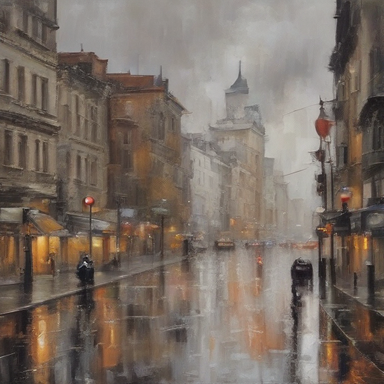

In [82]:
image, label = first_dataset[0]
image

In [83]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

first_dataset = WeatherDataset(annotations_file=csv_path, img_dir=img_path, transform=transform)

total_size = len(first_dataset)

train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    first_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

In [84]:
len(first_dataset), len(train_dataset), len(val_dataset), len(test_dataset)

(160, 128, 16, 16)

In [85]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [86]:
class WeatherClassifier(nn.Module):
    def __init__(self, num_classes=2):
        super(WeatherClassifier, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * 32 * 32, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        return self.net(x)

In [87]:
model = WeatherClassifier(num_classes=2)
print(str(model)[:500])

WeatherClassifier(
  (net): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=65536, out_features=128, bias=True)
    (


In [88]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [89]:
num_epochs = 6
train_losses, val_losses = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(train_loader, desc='Training'):
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * labels.size(0)
    
    train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc='Validation'):
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * labels.size(0)
    
    val_loss = running_loss / len(val_loader.dataset)
    val_losses.append(val_loss)
    print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

Validation: 100%|██████████| 1/1 [00:00<00:00,  3.23it/s]


Epoch 1/6, Train Loss: 0.9496, Val Loss: 0.7125


Validation: 100%|██████████| 1/1 [00:00<00:00,  2.73it/s]


Epoch 2/6, Train Loss: 0.5997, Val Loss: 0.5042


Validation: 100%|██████████| 1/1 [00:00<00:00,  3.28it/s]


...

Epoch 4/6, Train Loss: 0.1996, Val Loss: 0.0876


Validation: 100%|██████████| 1/1 [00:00<00:00,  3.31it/s]


Epoch 5/6, Train Loss: 0.0683, Val Loss: 0.0461


Validation: 100%|██████████| 1/1 [00:00<00:00,  3.51it/s]

Epoch 6/6, Train Loss: 0.0242, Val Loss: 0.0203


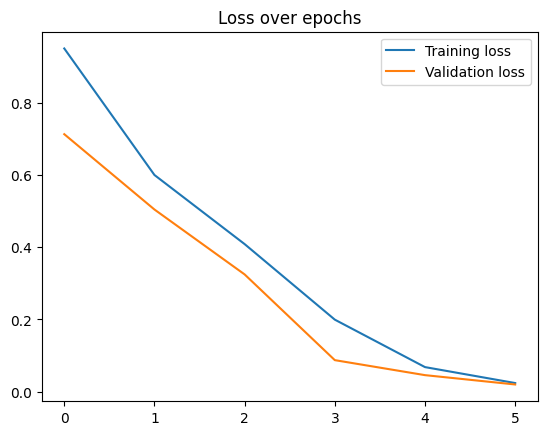

In [90]:
plt.plot(train_losses, label='Training loss')
plt.plot(val_losses, label='Validation loss')
plt.legend()
plt.title("Loss over epochs")
plt.show()

# Realistic or Artistic

In [91]:
art_to_idx = {"realistic": 0, "artistic": 1}

class ArtDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None):
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        image = Image.open(img_path).convert("RGB")
        label_name = self.img_labels.iloc[idx, 2]
        label = art_to_idx[label_name]
        if self.transform:
            image = self.transform(image)
        return image, label

In [92]:
second_dataset = ArtDataset(annotations_file=csv_path, img_dir=img_path)
print(second_dataset.img_labels.iloc[0,2])

artistic


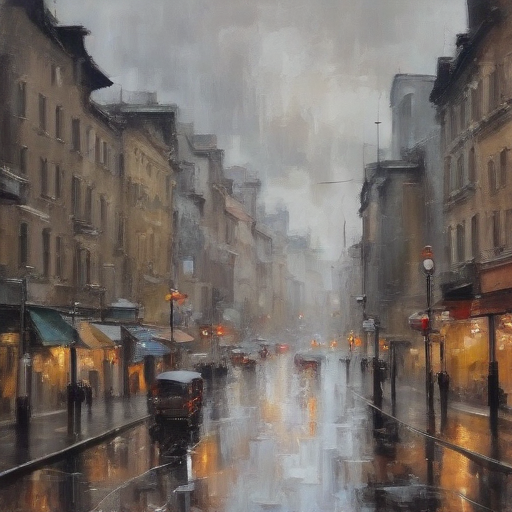

In [93]:
image, label = second_dataset[3]
image

In [94]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

second_dataset = ArtDataset(annotations_file=csv_path, img_dir=img_path, transform=transform)

total_size = len(second_dataset)

train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    second_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

In [95]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [96]:
class ArtClassifier(nn.Module):
    def __init__(self, num_classes=2):
        super(ArtClassifier, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * 32 * 32, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        return self.net(x)

In [97]:
model = ArtClassifier(num_classes=2)

In [100]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [101]:
num_epochs = 5
train_losses, val_losses = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(train_loader, desc='Training'):
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * labels.size(0)
    
    train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc='Validation'):
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * labels.size(0)
    
    val_loss = running_loss / len(val_loader.dataset)
    val_losses.append(val_loss)
    print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

Validation: 100%|██████████| 1/1 [00:00<00:00,  2.43it/s]


Epoch 1/5, Train Loss: 0.8804, Val Loss: 0.6531


Validation: 100%|██████████| 1/1 [00:00<00:00,  2.86it/s]


Epoch 2/5, Train Loss: 0.6653, Val Loss: 0.6000


Validation: 100%|██████████| 1/1 [00:00<00:00,  2.97it/s]


Epoch 3/5, Train Loss: 0.4101, Val Loss: 0.1299


Validation: 100%|██████████| 1/1 [00:00<00:00,  2.85it/s]


Epoch 4/5, Train Loss: 0.1811, Val Loss: 0.1121


Validation: 100%|██████████| 1/1 [00:00<00:00,  2.71it/s]

Epoch 5/5, Train Loss: 0.0795, Val Loss: 0.0255


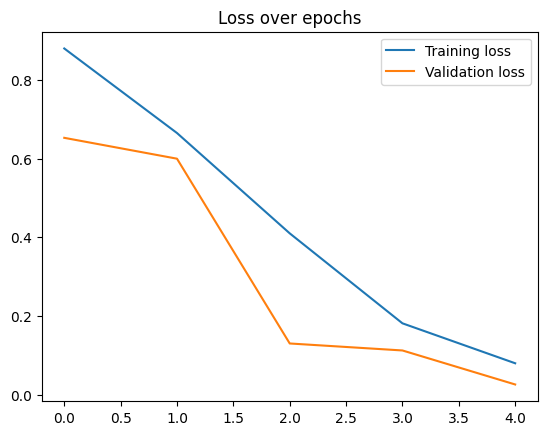

In [102]:
plt.plot(train_losses, label='Training loss')
plt.plot(val_losses, label='Validation loss')
plt.legend()
plt.title("Loss over epochs")
plt.show()

# Marked images
We are going to use the KMeans algorithm over a PCA reduced dataset to predict the marked images

In [103]:
img_dir = 'data/marked'
n_clusters_weather = 2
n_clusters_style = 2

In [104]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [106]:
resnet = models.resnet18(pretrained=True)
resnet.fc = torch.nn.Identity()
resnet.eval()

/home/clement/etudes/passau/applied_artificial_intelligence_lab/applied_ai_intro_task/.venv/lib64/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/clement/etudes/passau/applied_artificial_intelligence_lab/applied_ai_intro_task/.venv/lib64/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/clement/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:06<00:00, 7.46MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [107]:
filenames = [f for f in os.listdir(img_dir) if f.endswith((".jpg", ".png"))]
features = []

In [ ]:
for file in tqdm(filenames):
    path = os.path.join(img_dir, file)
    img = Image.open(path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0)
    with torch.no_grad():
        feat = resnet(img_tensor)
    features.append(feat.squeeze().numpy())

100%|██████████| 29/29 [00:02<00:00, 11.86it/s]


In [112]:
X = np.array(features)

pca = PCA(n_components=10)
X_reduced = pca.fit_transform(X)

In [113]:
kmeans_weather = KMeans(n_clusters=n_clusters_weather, random_state=42)
weather_preds = kmeans_weather.fit_predict(X_reduced)

kmeans_style = KMeans(n_clusters=n_clusters_style, random_state=42)
style_preds = kmeans_style.fit_predict(X_reduced)

In [114]:
df = pd.DataFrame({
    "filename": filenames,
    "predicted_weather": weather_preds,
    "predicted_style": style_preds
})
df

,filename,predicted_weather,predicted_style
0,image_01.png,0,0
1,image_05.png,0,0
2,image_08.png,1,1
3,image_09.png,1,1
4,image_14.png,0,0
5,image_15.png,0,0
6,image_16.png,1,1
7,image_18.png,1,1
8,image_19.png,0,0
9,image_21.png,1,1
